In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/competitions/birdclef-2026/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: codingmaster24
Your Kaggle Key: ··········


100%|██████████| 15.0G/15.0G [01:38<00:00, 164MB/s]



Extracting archive ./birdclef-2026/birdclef-2026.zip to ./birdclef-2026


In [4]:
import os

folder_path = "/content/birdclef-2026"

# List to store the details
csv_details = []

# Iterate through all files in the directory
for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        file_path = os.path.join(folder_path, filename)

        # Read only the first row to get column names and types quickly
        try:
            df_preview = pd.read_csv(file_path, nrows=5)

            for col in df_preview.columns:
                csv_details.append({
                    "File Name": filename,
                    "Column Name": col,
                    "Data Type": df_preview[col].dtype
                })
        except Exception as e:
            print(f"Could not read {filename}: {e}")

# Display as a structured DataFrame
details_df = pd.DataFrame(csv_details)
pd.set_option('display.max_rows', None) # Show everything
print(details_df)

                        File Name       Column Name Data Type
0                    taxonomy.csv     primary_label     int64
1                    taxonomy.csv     inat_taxon_id     int64
2                    taxonomy.csv   scientific_name    object
3                    taxonomy.csv       common_name    object
4                    taxonomy.csv        class_name    object
5                       train.csv     primary_label     int64
6                       train.csv  secondary_labels    object
7                       train.csv              type    object
8                       train.csv          latitude   float64
9                       train.csv         longitude   float64
10                      train.csv   scientific_name    object
11                      train.csv       common_name    object
12                      train.csv        class_name    object
13                      train.csv     inat_taxon_id     int64
14                      train.csv            author    object
15      

In [15]:
import pandas as pd

train = pd.read_csv("/content/birdclef-2026/train.csv")
taxonomy = pd.read_csv("/content/birdclef-2026/taxonomy.csv")
sub = pd.read_csv("/content/birdclef-2026/sample_submission.csv")
train_soundscape = pd.read_csv("/content/birdclef-2026/train_soundscapes_labels.csv")

In [5]:
train.head()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [10]:
train.tail()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
35544,yeofly1,[],['call'],-6.7281,-76.4181,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/762473/download,yeofly1/XC762473.ogg,XC
35545,yeofly1,[],"['call', ' song']",-16.0538,-49.6040,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,JAYRSON ARAUJO DE OLIVEIRA,by-nc-sa,5.0,https://xeno-canto.org/818328/download,yeofly1/XC818328.ogg,XC
35546,yeofly1,[],['song'],5.9002,-74.8485,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,Jerome Fischer,by-nc-sa,4.0,https://xeno-canto.org/425545/download,yeofly1/XC425545.ogg,XC
35547,yeofly1,[],['song'],3.3821,-61.4464,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/456230/download,yeofly1/XC456230.ogg,XC
35548,yeofly1,[],['song'],-19.4144,-42.4151,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,Roney Souza,by-nc-sa,5.0,https://xeno-canto.org/298884/download,yeofly1/XC298884.ogg,XC


In [6]:
train.describe()

,latitude,longitude,inat_taxon_id,rating
count,35549.000000,35549.000000,3.554900e+04,35549.000000
mean,-8.166453,-60.744700,8.022132e+04,2.600748
std,20.254421,25.434547,2.422476e+05,2.070471
min,-54.857400,-159.655600,7.000000e+00,0.000000
25%,-23.363600,-75.141700,8.830000e+03,0.000000
50%,-14.882500,-58.130200,1.595700e+04,3.500000
75%,4.642900,-48.733500,1.962700e+04,4.500000
max,69.578000,175.323900,1.595929e+06,5.000000


In [7]:
taxonomy.head()

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


In [8]:
taxonomy.tail()

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
229,yebela1,16714,Elaenia flavogaster,Yellow-bellied Elaenia,Aves
230,yecmac,73272,Primolius auricollis,Golden-collared Macaw,Aves
231,yecpar,19215,Brotogeris chiriri,Yellow-chevroned Parakeet,Aves
232,yehcar1,1432779,Daptrius chimachima,Yellow-headed Caracara,Aves
233,yeofly1,16567,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves


In [9]:
taxonomy.describe()

,inat_taxon_id
count,2.340000e+02
mean,1.285029e+05
std,3.071946e+05
min,7.000000e+00
25%,1.091650e+04
50%,1.918850e+04
75%,4.715800e+04
max,1.595929e+06


In [11]:
sub.head()

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


In [12]:
sub.tail()

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


In [13]:
sub.describe()

,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,22967,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
count,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
mean,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
std,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
min,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
25%,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
50%,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
75%,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
max,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


In [16]:
train_soundscape.head()

,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380


In [17]:
train_soundscape.tail()

,filename,start,end,primary_label
1473,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:35,00:00:40,555146;65380
1474,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:40,00:00:45,517063;555146
1475,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:45,00:00:50,517063;555146
1476,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:50,00:00:55,517063;555146;66971
1477,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:55,00:01:00,517063;555146;66971


In [18]:
train_soundscape.describe()

,filename,start,end,primary_label
count,1478,1478,1478,1478
unique,66,12,12,251
top,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,23158;24279;24321;517063;555146;65380;66971
freq,24,126,126,54


### Exploratory Data Analysis and Feature Engineering for `train.csv`

In [19]:
print('Unique primary_label in train:', train['primary_label'].nunique())
print('Top 10 primary_label in train:')
display(train['primary_label'].value_counts().head(10))

print('\nUnique class_name in train:', train['class_name'].nunique())
print('Top 10 class_name in train:')
display(train['class_name'].value_counts().head(10))

print('\nUnique collection in train:', train['collection'].nunique())
print('Top 10 collection in train:')
display(train['collection'].value_counts().head(10))

Unique primary_label in train: 206
Top 10 primary_label in train:


,count
primary_label,
rubthr1,499
banana,498
fepowl,497
soulap1,497
houspa,496
coffal1,495
osprey,495
socfly1,494
compau,493



Unique class_name in train: 5
Top 10 class_name in train:


,count
class_name,
Aves,34799
Amphibia,451
Insecta,199
Mammalia,99
Reptilia,1



Unique collection in train: 2
Top 10 collection in train:


,count
collection,
XC,23043
iNat,12506


The `type` and `secondary_labels` columns seem to contain string representations of lists. Let's convert them to actual lists and count the occurrences of each type and secondary label. This will be a part of feature engineering.

In [20]:
import ast

# Convert 'type' and 'secondary_labels' from string representation of lists to actual lists
train['type'] = train['type'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
train['secondary_labels'] = train['secondary_labels'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Explode the 'type' column to count individual types
all_types = train['type'].explode()
print('\nTop 10 types of recordings:')
display(all_types.value_counts().head(10))

# Explode the 'secondary_labels' column to count individual secondary labels
all_secondary_labels = train['secondary_labels'].explode()
print('\nTop 10 secondary labels:')
display(all_secondary_labels.value_counts().head(10))


Top 10 types of recordings:


,count
type,
song,10692
call,8715
song,2164
flight call,868
alarm call,749
duet,302
flight call,260
call,251
dawn song,249



Top 10 secondary labels:


,count
secondary_labels,
grekis,624
whtdov,468
undtin1,315
yecpar,226
rufhor2,225
saffin,183
picpig2,172
trokin,171
soulap1,154


Let's also look at the distribution of the `rating` column, which is a numerical feature.

### Feature Engineering and EDA for `train_soundscapes_labels.csv`

In [22]:
import numpy as np

# Convert 'start' and 'end' to timedelta objects
train_soundscape['start_td'] = pd.to_timedelta(train_soundscape['start'])
train_soundscape['end_td'] = pd.to_timedelta(train_soundscape['end'])

# Calculate duration in seconds
train_soundscape['duration'] = (train_soundscape['end_td'] - train_soundscape['start_td']).dt.total_seconds()

print('Distribution of recording durations in train_soundscape:')
display(train_soundscape['duration'].describe())

# Explode the 'primary_label' column in train_soundscape to count individual labels
train_soundscape['primary_label_list'] = train_soundscape['primary_label'].apply(lambda x: str(x).split(';') if isinstance(x, str) else [])
all_soundscape_labels = train_soundscape['primary_label_list'].explode()
print('\nTop 10 primary labels in train_soundscape:')
display(all_soundscape_labels.value_counts().head(10))

Distribution of recording durations in train_soundscape:


,duration
count,1478.0
mean,5.0
std,0.0
min,5.0
25%,5.0
50%,5.0
75%,5.0
max,5.0



Top 10 primary labels in train_soundscape:


,count
primary_label_list,
65380,666
517063,626
22973,426
555146,420
23158,350
24279,346
24321,344
22967,310
66971,298


### Geographical Distribution of Recordings from `train.csv`

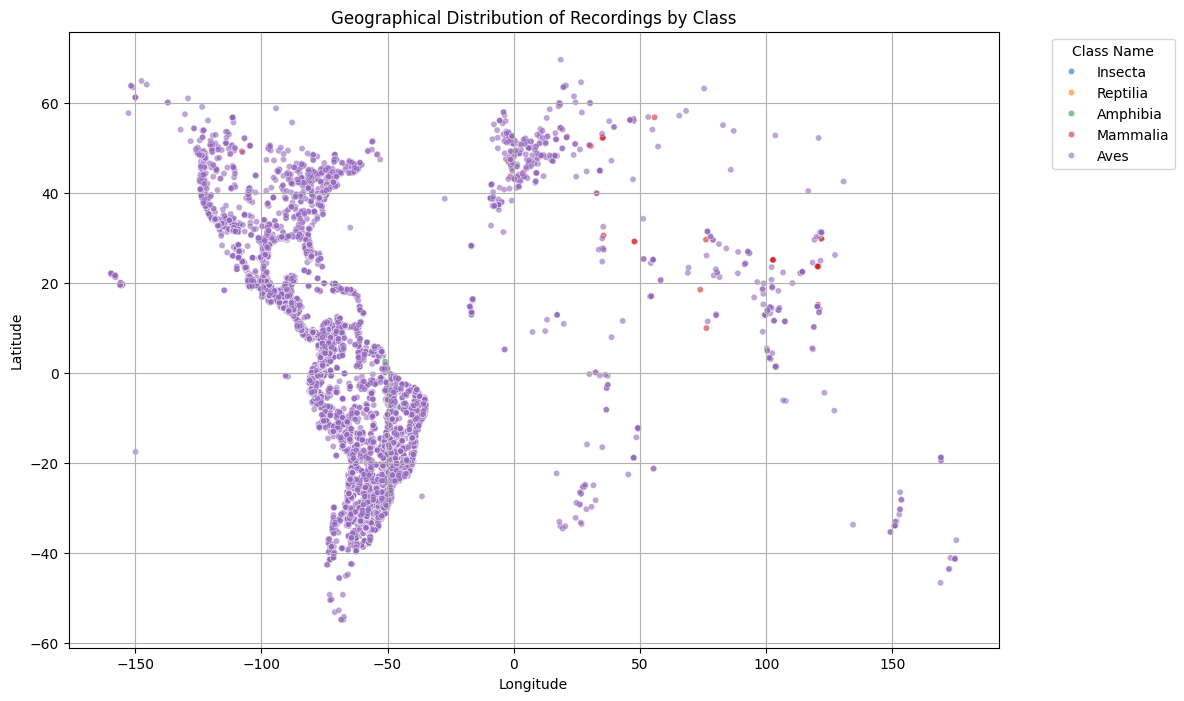

In [23]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=train, x='longitude', y='latitude', hue='class_name', s=20, alpha=0.6)
plt.title('Geographical Distribution of Recordings by Class')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Class Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

### Word Cloud of Common Names from `train.csv`

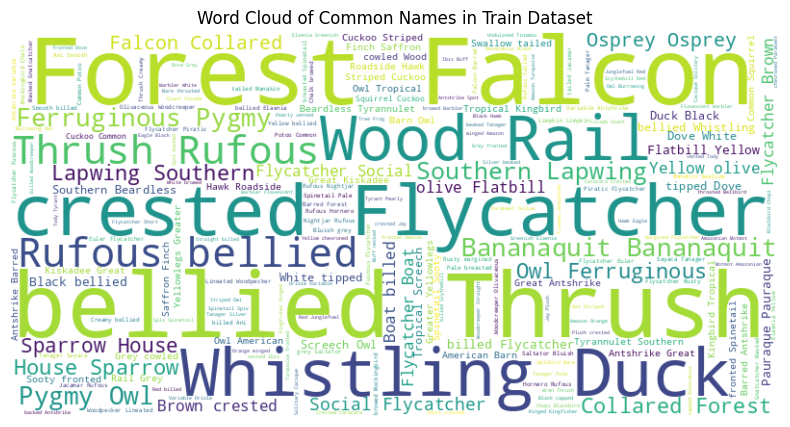

In [24]:
from wordcloud import WordCloud
from collections import Counter

# Combine all common names into a single string
all_common_names = ' '.join(train['common_name'].dropna().astype(str).tolist())

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_common_names)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Common Names in Train Dataset')
plt.show()

### Distribution of Licenses and Authors in `train.csv`

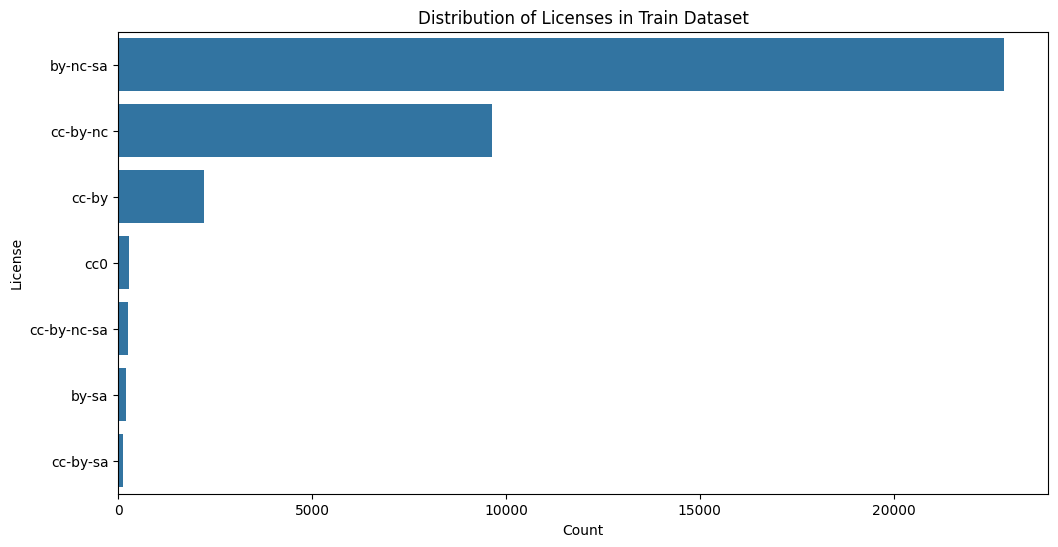

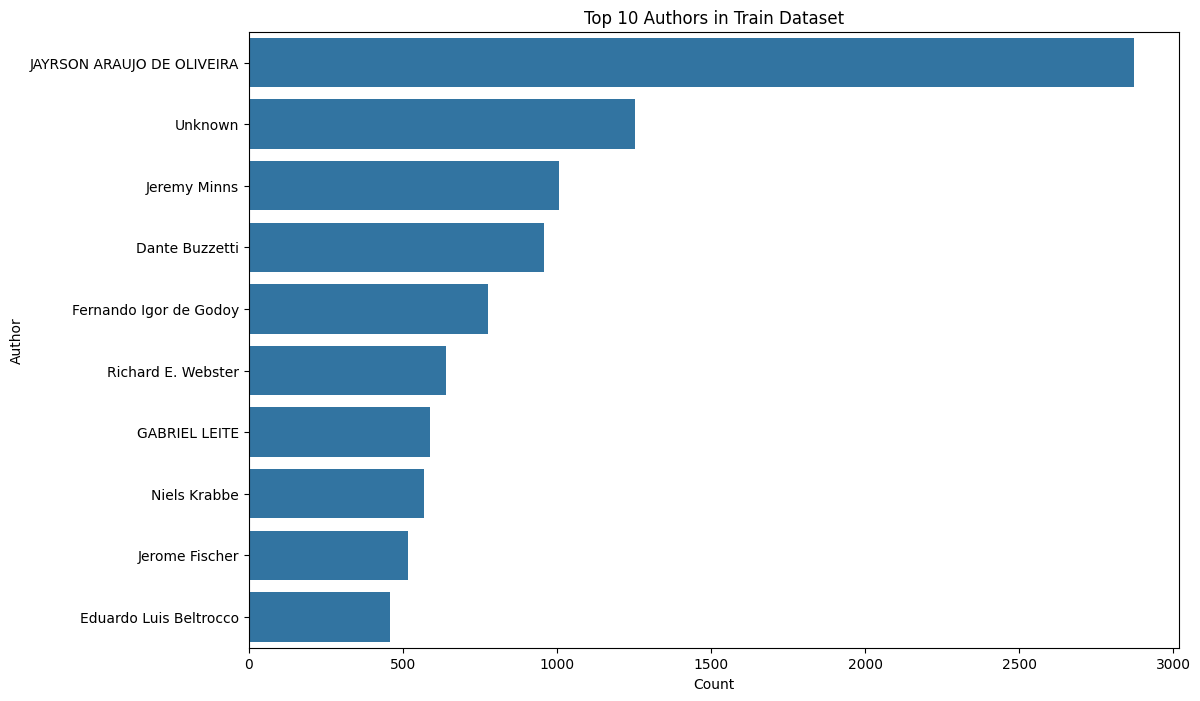

In [25]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train, y='license', order=train['license'].value_counts().index)
plt.title('Distribution of Licenses in Train Dataset')
plt.xlabel('Count')
plt.ylabel('License')
plt.show()

plt.figure(figsize=(12, 8))
sns.countplot(data=train, y='author', order=train['author'].value_counts().head(10).index)
plt.title('Top 10 Authors in Train Dataset')
plt.xlabel('Count')
plt.ylabel('Author')
plt.show()

### Relationship between `class_name` and `rating`

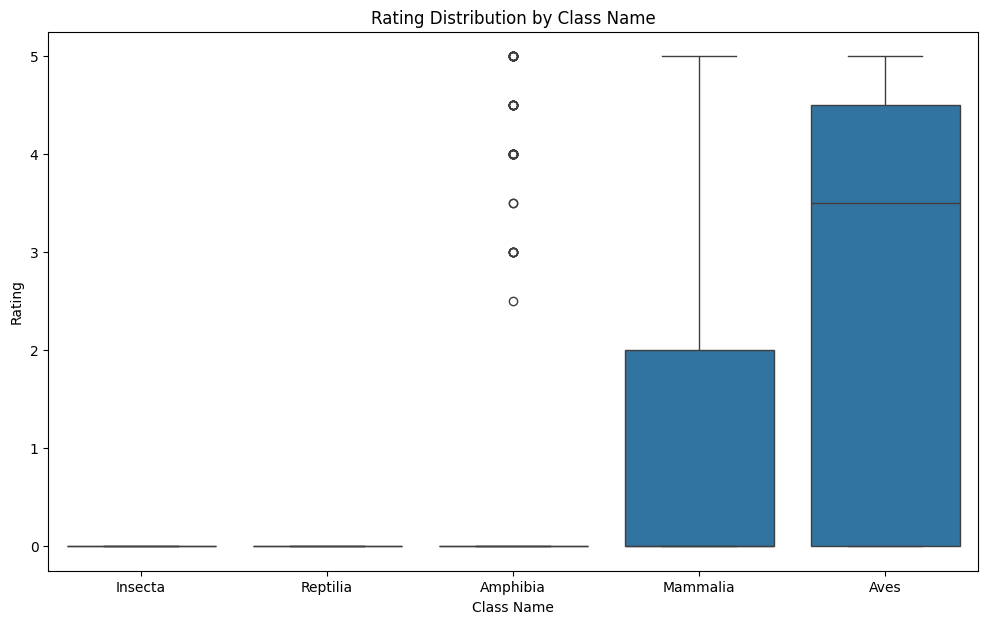

In [26]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=train, x='class_name', y='rating')
plt.title('Rating Distribution by Class Name')
plt.xlabel('Class Name')
plt.ylabel('Rating')
plt.show()

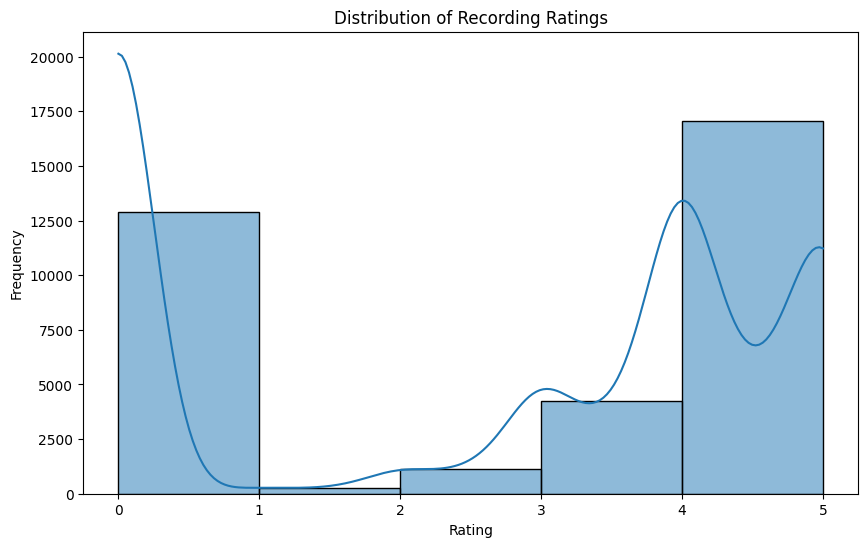

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(train['rating'], bins=5, kde=True)
plt.title('Distribution of Recording Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [27]:
# Install necessary libraries
!pip install torchaudio librosa scikit-learn matplotlib seaborn

In [28]:
import torch
import torchaudio
import torchaudio.transforms as T
import librosa
import librosa.display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


### Custom PyTorch Dataset for Audio Classification

### Define the PyTorch Model Architecture

In [31]:
class BirdClassifier(nn.Module):
    def __init__(self, num_classes):
        super(BirdClassifier, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3, 3), padding=(1, 1)),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=(2, 2)),

            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=(1, 1)),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=(2, 2)),

            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=(1, 1)),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=(2, 2))
        )

        # Dynamically calculate the output features from conv layers
        # This requires a dummy pass to determine the size
        self._features_dim = self._get_conv_output((1, 128, 157))

        self.fc_layers = nn.Sequential(
            nn.Linear(self._features_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def _get_conv_output(self, shape):
        batch_size = 1
        input = torch.autograd.Variable(torch.rand(batch_size, *shape))
        output_feat = self.conv_layers(input)
        n_size = output_feat.data.view(batch_size, -1).size(1)
        return n_size

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # Flatten the output
        x = self.fc_layers(x)
        return x

# Instantiate the model
model = BirdClassifier(num_classes=num_classes).to(device)
print("Model architecture:")
print(model)


Model architecture:
BirdClassifier(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=38912, out_features=512, bias=True)
    (1): ReLU()

### Training and Evaluation Functions

In [ ]:
def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train()
    train_losses = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")
    return train_losses

def evaluate_model(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc="Evaluation"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    avg_loss = running_loss / len(data_loader.dataset)
    accuracy = correct_predictions / len(data_loader.dataset)
    print(f"Evaluation Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")
    return avg_loss, accuracy, all_labels, all_predictions

# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
print("Starting model training...")
train_losses = train_model(model, train_loader, criterion, optimizer, num_epochs=5) # Reduced epochs for demonstration

# Evaluate the model on the validation set
print("\nEvaluating model on validation set...")
val_loss, val_accuracy, val_labels, val_predictions = evaluate_model(model, val_loader, criterion)

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Starting model training...


Epoch 1/5 - Training:   0%|          | 0/889 [00:00<?, ?it/s]

Error loading audio file /content/birdclef-2026/train_audio/greela/greela/XC65738.ogg: Failed to create AudioDecoder for /content/birdclef-2026/train_audio/greela/greela/XC65738.ogg: Could not open input file: /content/birdclef-2026/train_audio/greela/greela/XC65738.ogg No such file or directoryError loading audio file /content/birdclef-2026/train_audio/fusfly1/fusfly1/XC2200.ogg: Failed to create AudioDecoder for /content/birdclef-2026/train_audio/fusfly1/fusfly1/XC2200.ogg: Could not open input file: /content/birdclef-2026/train_audio/fusfly1/fusfly1/XC2200.ogg No such file or directory

Error loading audio file /content/birdclef-2026/train_audio/pabspi1/pabspi1/iNat519282.ogg: Failed to create AudioDecoder for /content/birdclef-2026/train_audio/pabspi1/pabspi1/iNat519282.ogg: Could not open input file: /content/birdclef-2026/train_audio/pabspi1/pabspi1/iNat519282.ogg No such file or directoryError loading audio file /content/birdclef-2026/train_audio/stbwoo2/stbwoo2/XC647605.ogg: Fa

In [30]:
class BirdAudioDataset(Dataset):
    def __init__(self, dataframe, audio_dir, labels_map, target_sample_rate=16000, n_mels=128, n_fft=2048, hop_length=512, max_audio_len=5*16000):
        self.dataframe = dataframe
        self.audio_dir = audio_dir
        self.labels_map = labels_map
        self.target_sample_rate = target_sample_rate
        self.max_audio_len = max_audio_len

        # Mel Spectrogram transform
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=target_sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )

    def __len__(self):
        return len(self.dataframe)

    def _load_audio(self, filepath):
        try:
            waveform, sample_rate = torchaudio.load(filepath)
            if sample_rate != self.target_sample_rate:
                resampler = T.Resample(orig_freq=sample_rate, new_freq=self.target_sample_rate)
                waveform = resampler(waveform)
            return waveform
        except Exception as e:
            print(f"Error loading audio file {filepath}: {e}")
            return None

    def _preprocess_audio(self, waveform):
        # Pad or truncate audio to max_audio_len
        if waveform.shape[1] > self.max_audio_len:
            waveform = waveform[:, :self.max_audio_len]
        elif waveform.shape[1] < self.max_audio_len:
            padding = self.max_audio_len - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, padding), 'constant', 0)

        # Convert to Mel Spectrogram and then to log scale
        mel_spec = self.mel_spectrogram(waveform)
        mel_spec = T.AmplitudeToDB()(mel_spec)
        return mel_spec

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        filename = row['filename']
        primary_label = row['primary_label']

        # Construct full audio file path
        audio_path = os.path.join(self.audio_dir, primary_label, filename)

        waveform = self._load_audio(audio_path)

        if waveform is None:
            # Return a dummy tensor if audio loading fails
            dummy_mel_spec = torch.zeros(1, self.mel_spectrogram.n_mels, self.max_audio_len // self.mel_spectrogram.hop_length + 1)
            label = torch.tensor(self.labels_map[primary_label], dtype=torch.long)
            return dummy_mel_spec, label

        mel_spec = self._preprocess_audio(waveform)
        label = torch.tensor(self.labels_map[primary_label], dtype=torch.long)

        return mel_spec, label

# Prepare labels
# Load train and sample submission to get all possible labels
all_labels_in_train = train['primary_label'].unique()
submission_labels = sub.columns[1:].tolist() # Exclude 'row_id'

# Ensure we only consider labels that exist in both for consistent mapping or handle new labels as 'unknown'
# For this task, we will focus on labels present in train.csv

# Filter out primary labels that appear only once to avoid issues with stratified split
label_counts = train['primary_label'].value_counts()
single_occurrence_labels = label_counts[label_counts < 2].index
train_filtered = train[~train['primary_label'].isin(single_occurrence_labels)]

label_encoder = LabelEncoder()
# Fit on all unique primary labels from the filtered training data
label_encoder.fit(train_filtered['primary_label'].unique())

# Create a mapping from original label to encoded integer
labels_map = {label: idx for idx, label in enumerate(label_encoder.classes_)}
num_classes = len(labels_map)

print(f"Number of classes: {num_classes}")
# print("Label mapping:", labels_map)

# Split the training data for actual training and validation using the filtered DataFrame
train_df, val_df = train_test_split(train_filtered, test_size=0.2, random_state=42, stratify=train_filtered['primary_label'])

print(f"Training data samples: {len(train_df)}")
print(f"Validation data samples: {len(val_df)}")

# Define audio directory (assuming audio files are organized by primary_label folders within a 'train_audio' directory)
# The user indicated '/content/birdclef-2026' as the base, so let's assume audio is in '/content/birdclef-2026/train_audio'
AUDIO_DIR = '/content/birdclef-2026/train_audio' # This path needs to be confirmed/adjusted based on actual audio file structure

# Create Dataset and DataLoader
train_dataset = BirdAudioDataset(train_df, AUDIO_DIR, labels_map)
val_dataset = BirdAudioDataset(val_df, AUDIO_DIR, labels_map)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("DataLoaders created.")

Number of classes: 202
Training data samples: 28436
Validation data samples: 7109
DataLoaders created.
